#Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pylab as plt 
from scipy.stats import iqr
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Load and read the data

In [2]:
DATA_PATH = r"C:\Users\sojay\DS\VS_Code\venv\Project_3\synthetic_food_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Sample records \n {df.sample(10)}")
print(f"Top 10 records \n {df.head(10)}")
print(f"Bottom 10 records \n {df.tail(10)}")

Sample records 
          Calories    Protein        Fat      Carbs      Sugar     Fiber  \
23925  284.402466   5.096112  11.310054  34.374153  17.541591  0.597809   
22567  175.828138  11.074619   5.422661  27.839402   3.199029  1.355617   
18335  339.204873   7.719812  24.233943  27.128352   7.053023  2.116319   
16310  303.083746  11.461018  10.380597  38.164526   6.977159  2.641000   
28977  334.705817   7.962083   9.253885  41.341443   3.756854  0.136425   
6009   304.859442  14.853074  15.928953  27.618025   5.545909  2.482789   
21378  367.923976  25.370542  18.188826   0.211710   0.283339  0.000000   
23912  279.675181  15.184474  11.807338  31.258775   5.236118  2.080399   
22536  277.018144  13.704434  21.663522  27.758188   6.119601  1.610283   
11292  111.990547   0.104665   0.382241  24.911504  22.626980  4.355629   

           Sodium  Cholesterol  Glycemic_Index  Water_Content  Serving_Size  \
23925  292.365237    20.535691       79.268261      32.188248     73.346899   

#Missing value and Handling of missing values and null values

In [ ]:
print(f"\n Total data{df.shape}")

missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Count', ascending=False)
print("\n Missing Value Summary:\n", missing_summary)
df = df.dropna()
df = df.drop_duplicates()
print(df.shape)
df.columns

print("\n Missing Value Summary after handling missing values:\n", missing_summary)

nutrient_col = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content']
for Feature_100 in nutrient_col:
    df[Feature_100 + "_per_100g"] = (df[Feature_100] / df["Serving_Size"]) * 100
Feature = [f"{col}_per_100g" for col in nutrient_col]


 Total data(31260, 26)

 Missing Value Summary:
                          Missing Count  Missing Percentage
Calories                             0                 0.0
Protein                              0                 0.0
Fat                                  0                 0.0
Carbs                                0                 0.0
Sugar                                0                 0.0
Fiber                                0                 0.0
Sodium                               0                 0.0
Cholesterol                          0                 0.0
Glycemic_Index                       0                 0.0
Water_Content                        0                 0.0
Serving_Size                         0                 0.0
Meal_Type                            0                 0.0
Preparation_Method                   0                 0.0
Is_Vegan                             0                 0.0
Is_Gluten_Free                       0                 0.0
Food_N

#Class distribution


 Food Name Class Distribution:
 Food_Name
Pizza        5900
Burger       4923
Donut        4454
Pasta        3959
Sushi        3450
Ice Cream    2954
Steak        1981
Apple        1471
Banana       1184
Salad         984
Name: count, dtype: int64


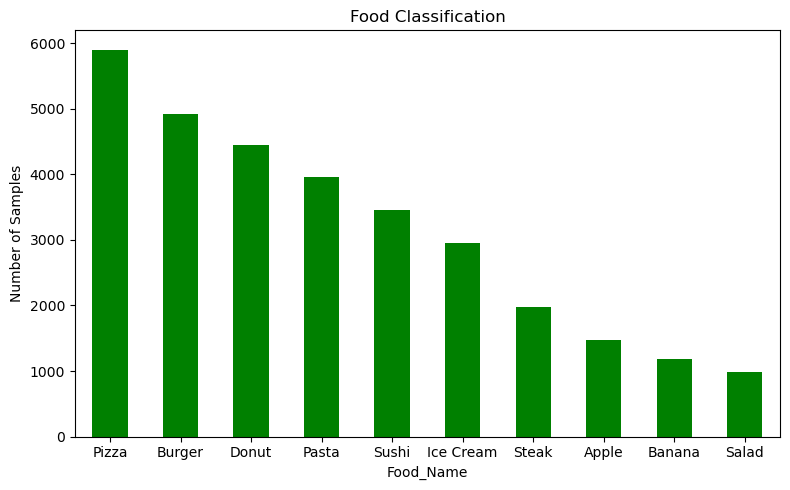

C:\Users\sojay\AppData\Local\Temp\ipykernel_14088\1794713410.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 50), random_state=42))


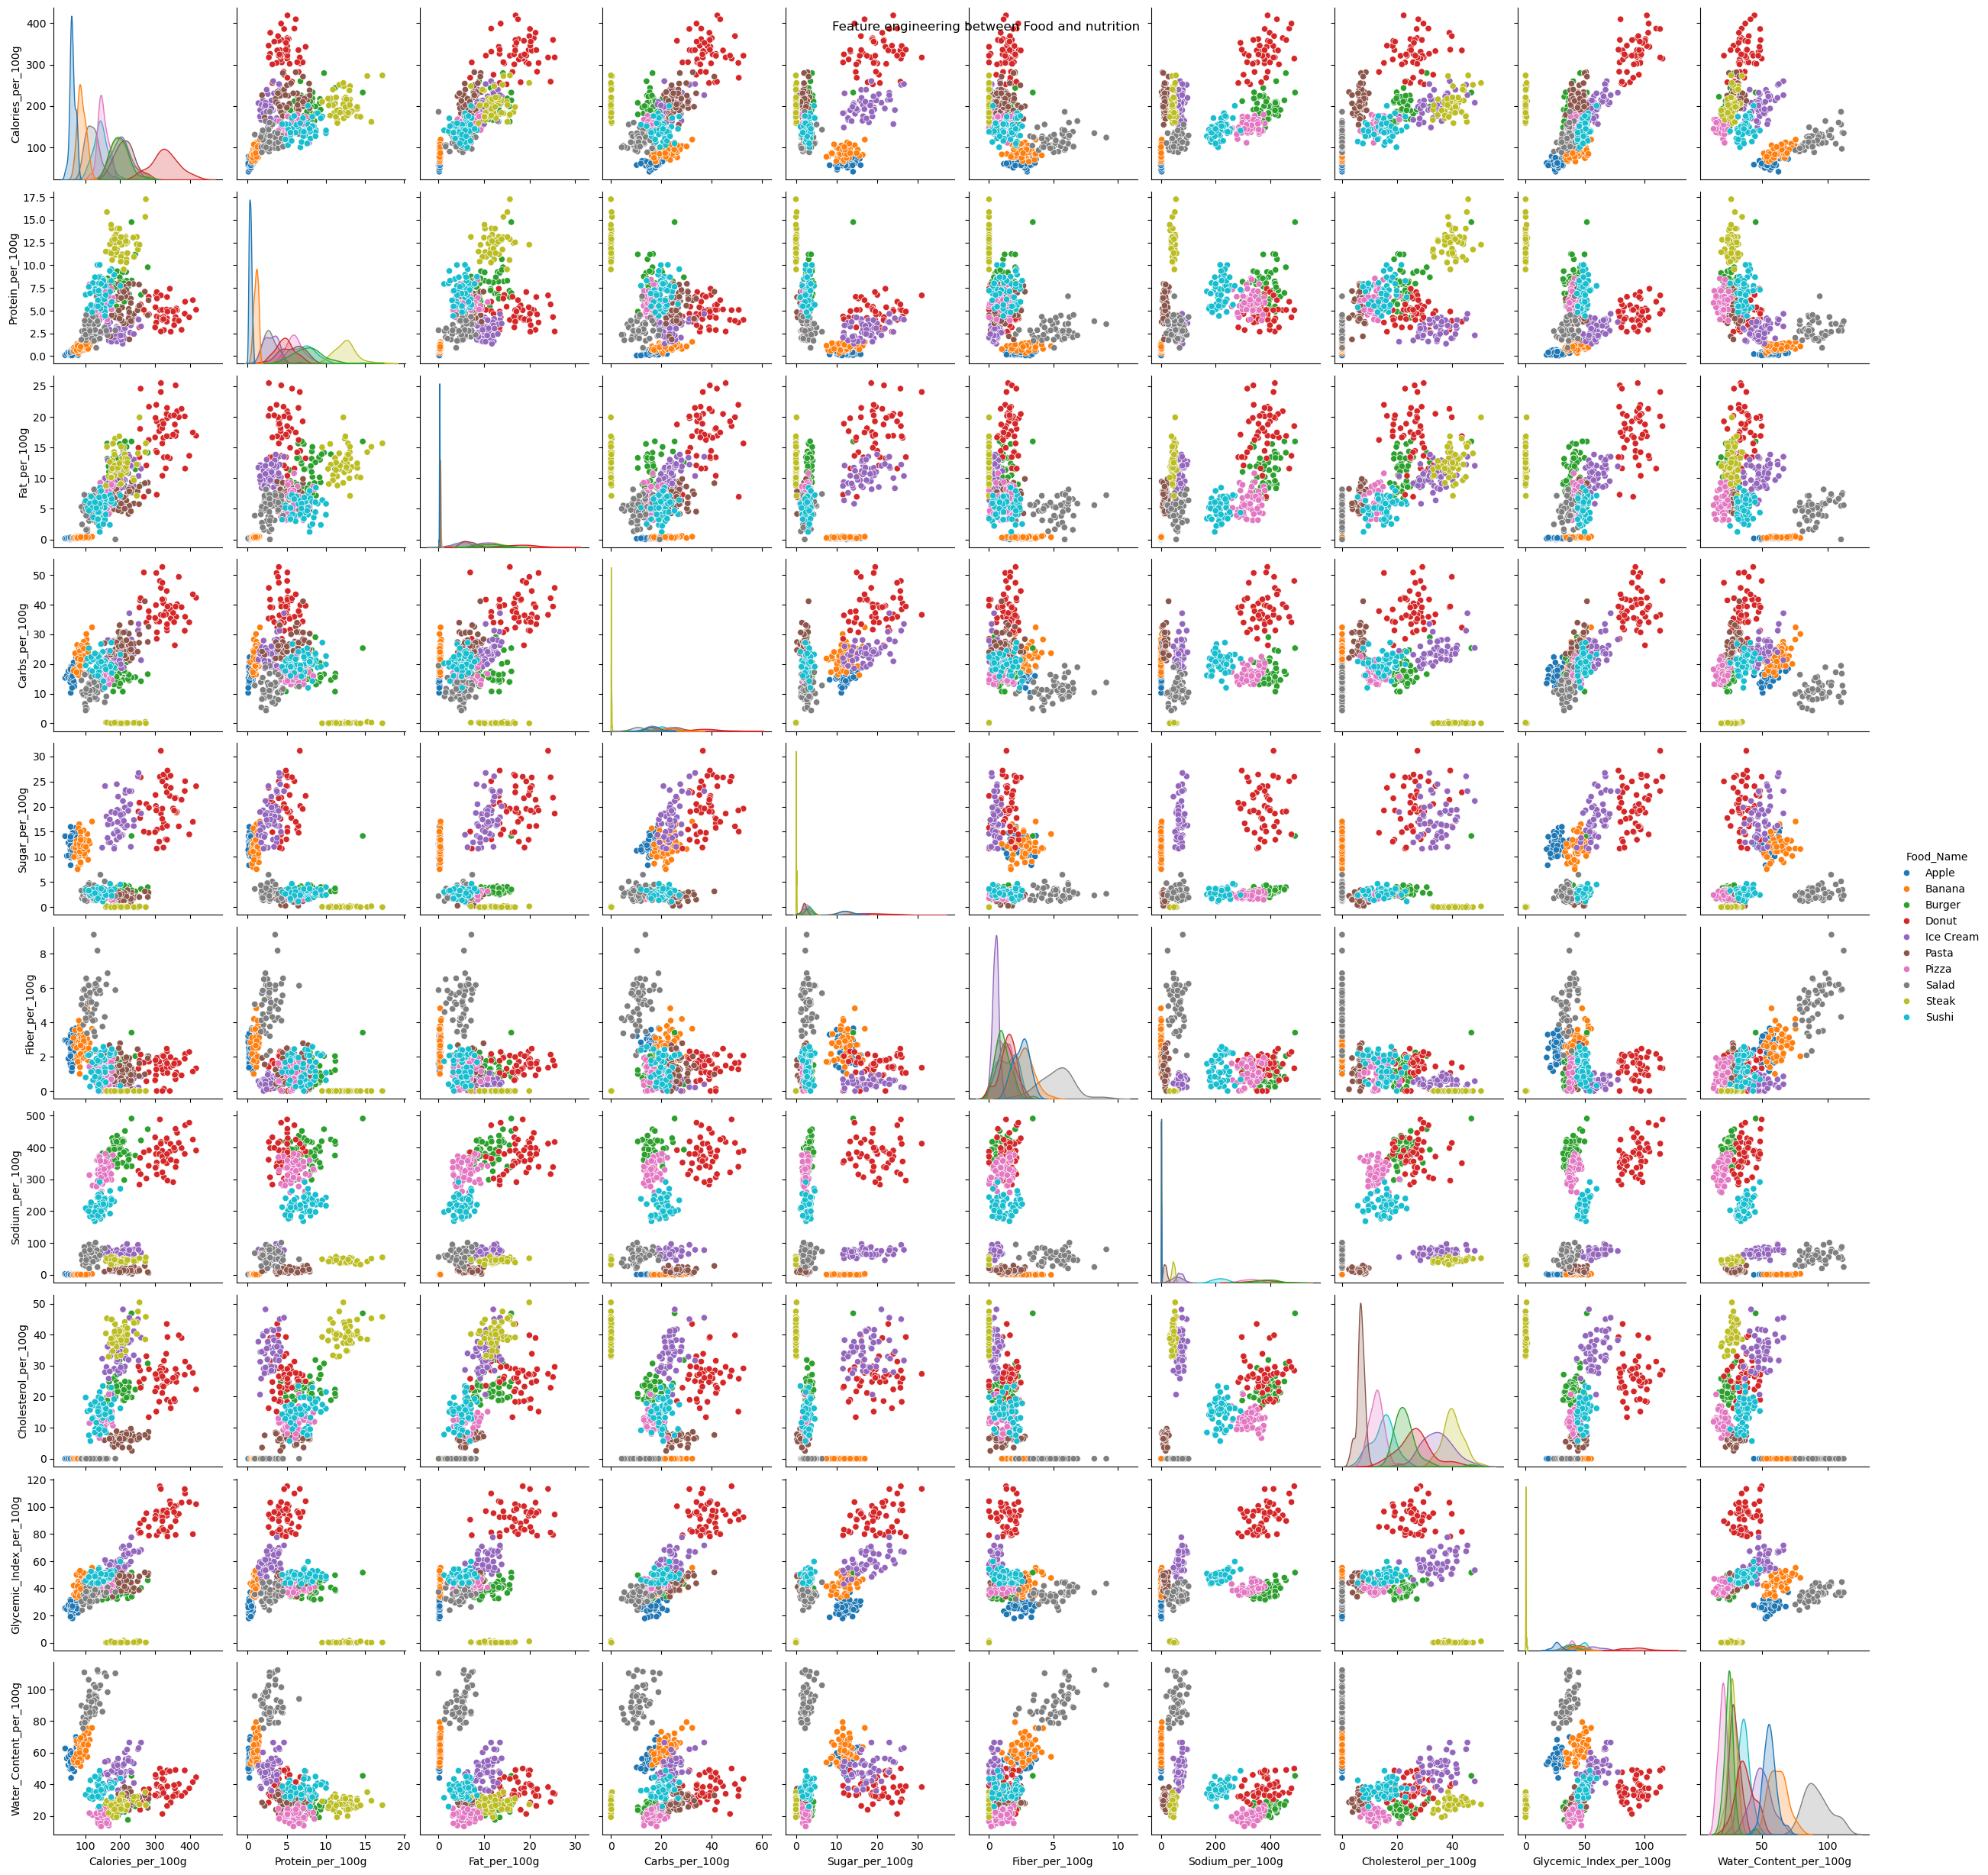

In [9]:
Food_Classification = df['Food_Name'].value_counts()
print("\n Food Name Class Distribution:\n", Food_Classification)
plt.figure(figsize=(8,5))
Food_Classification.plot(kind='bar', color='green')
plt.title('Food Classification')
plt.xlabel('Food_Name')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#box plot
sample_df = (
    df.groupby("Food_Name", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 50), random_state=42))
)

sns.pairplot(sample_df, hue="Food_Name", vars=Feature)
plt.suptitle("Feature engineering between Food and nutrition")
plt.show()


#Feature Engineering with PCA

 Class Labels Encoded: ['Apple', 'Banana', 'Burger', 'Donut', 'Ice Cream', 'Pasta', 'Pizza', 'Salad', 'Steak', 'Sushi']
{0: 'Apple', 1: 'Banana', 2: 'Burger', 3: 'Donut', 4: 'Ice Cream', 5: 'Pasta', 6: 'Pizza', 7: 'Salad', 8: 'Steak', 9: 'Sushi'}


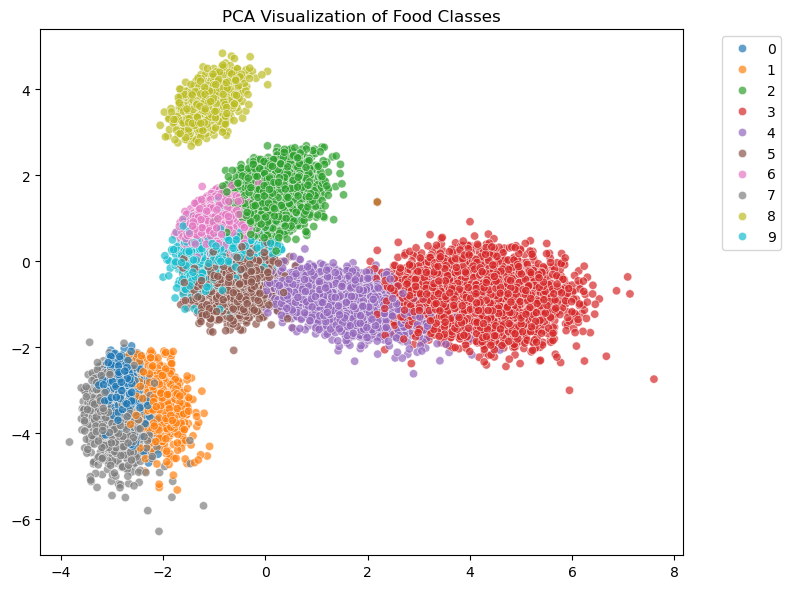

 Explained Variance Ratio: [0.39589626 0.2906747 ]


In [10]:
label_encoder = LabelEncoder()
df['Food_Name_Label'] = label_encoder.fit_transform(df['Food_Name'])
print(" Class Labels Encoded:", list(label_encoder.classes_))

X = df[Feature]
y = df["Food_Name_Label"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(dict(enumerate(label_encoder.classes_)))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Food_Name_Label'],
    palette="tab10",
    alpha=0.7)
plt.title("PCA Visualization of Food Classes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(" Explained Variance Ratio:", pca.explained_variance_ratio_)

#Inner class variation

In [14]:
sample_df = (
    df.groupby("Food_Name", group_keys=False)
      .apply(lambda x: x.sample(5, random_state=42))
)

sample_df

C:\Users\sojay\AppData\Local\Temp\ipykernel_14088\1066598102.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(5, random_state=42))


,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Protein_per_100g,Fat_per_100g,Carbs_per_100g,Sugar_per_100g,Fiber_per_100g,Sodium_per_100g,Cholesterol_per_100g,Glycemic_Index_per_100g,Water_Content_per_100g,Food_Name_Label
18920,88.831447,0.669344,0.398466,27.351470,20.585923,4.569030,2.131523,0.000000,46.051619,83.131396,...,0.435488,0.259249,17.795385,13.393592,2.972697,1.386809,0.000000,29.962057,54.086863,0
3795,93.549926,0.936182,0.150709,24.465138,16.105486,2.413314,1.884108,0.000000,34.943445,89.185963,...,0.574389,0.092467,15.010439,9.881425,1.480674,1.155983,0.000000,21.439342,54.719515,0
26944,91.157253,0.383083,0.385768,26.279071,18.966745,2.786889,1.032238,0.000000,41.116436,84.919454,...,0.244549,0.246262,16.775738,12.107777,1.779063,0.658948,0.000000,26.247448,54.209926,0
1485,95.100212,0.362261,0.268903,26.207549,20.338877,3.887874,0.086660,0.000000,44.482498,71.297868,...,0.223792,0.166118,16.190064,12.564614,2.401786,0.053535,0.000000,27.479659,44.045213,0
4602,101.507151,0.754311,0.385415,26.483842,21.910286,2.691525,1.315538,0.000000,38.493060,88.429502,...,0.543260,0.277578,19.073849,15.779942,1.938455,0.947460,0.000000,27.722972,63.687548,0
9236,97.010961,1.338769,0.473392,30.501184,19.450946,2.111370,1.703918,0.000000,54.851319,74.842735,...,1.136110,0.401731,25.884001,16.506517,1.791757,1.445984,0.000000,46.548082,63.513255,1
25536,119.988986,1.250650,0.407044,26.864774,16.552074,5.485819,0.000000,0.000000,54.121872,65.271463,...,1.099847,0.357963,23.625432,14.556233,4.824342,0.000000,0.000000,47.595882,57.401061,1
28719,113.736062,0.838404,0.248831,23.435669,13.288985,3.403860,0.399517,0.000000,49.812446,77.192172,...,0.707096,0.209860,19.765254,11.207709,2.870759,0.336946,0.000000,42.010989,65.102594,1
2363,105.863386,1.806631,0.399530,27.445043,13.241941,3.395617,0.584554,0.000000,48.782175,71.550170,...,1.371960,0.303404,20.841844,10.055967,2.578642,0.443912,0.000000,37.045322,54.335402,1
26247,107.149662,1.409277,0.417249,23.921019,17.267492,3.808535,0.876523,0.000000,59.819238,78.814908,...,1.130931,0.334838,19.196381,13.856991,3.056311,0.703401,0.000000,48.004346,63.248184,1


# Statistical ananlysis

In [17]:
print(f"Statistical analysis\n {df.describe()}")
print(df.dtypes)

Statistical analysis
            Calories       Protein           Fat         Carbs         Sugar  \
count  31260.000000  31260.000000  31260.000000  31260.000000  31260.000000   
mean     271.264635      9.373595     12.318521     28.711059      8.398251   
std      101.464986      7.324500      7.685144     11.612947      7.331201   
min       60.786204      0.000000      0.000000      0.000000      0.000000   
25%      210.226038      3.853169      8.237307     25.086253      3.735358   
50%      281.551993      9.077022     11.563735     29.662508      5.491571   
75%      329.557312     12.665367     15.783221     34.601958     14.375863   
max     1289.956763     81.761772     88.619611    140.585537     78.548162   

              Fiber        Sodium   Cholesterol  Glycemic_Index  \
count  31260.000000  31260.000000  31260.000000    31260.000000   
mean       1.868721    330.420394     26.380091       63.752078   
std        1.603749    300.206402     22.608649       23.310749  

#Outliers

In [18]:
iqr_values = df[Feature].apply(iqr)
print(f"Quartile Range \n {iqr_values}")
outlier_summary = {}

for col in Feature:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    iqr_range = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * iqr_range) | (df[col] > Q3 + 1.5 * iqr_range)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(
    outlier_summary,
    orient='index',
    columns=['Outlier_Count']
)

outlier_df
outlier_df['Outlier_%'] = (outlier_df['Outlier_Count'] / len(df)) * 100
outlier_df.sort_values(by='Outlier_%', ascending=False)


Quartile Range 
 Calories_per_100g           78.035625
Protein_per_100g             3.221441
Fat_per_100g                 6.556020
Carbs_per_100g              10.494277
Sugar_per_100g              11.042982
Fiber_per_100g               1.108391
Sodium_per_100g            310.140432
Cholesterol_per_100g        16.786725
Glycemic_Index_per_100g     14.564842
Water_Content_per_100g      17.920389
dtype: float64


,Outlier_Count,Outlier_%
Glycemic_Index_per_100g,6581,21.052463
Carbs_per_100g,2596,8.304543
Calories_per_100g,1627,5.204734
Fiber_per_100g,1469,4.699296
Protein_per_100g,1289,4.123480
Water_Content_per_100g,1224,3.915547
Fat_per_100g,607,1.941779
Cholesterol_per_100g,47,0.150352
Sugar_per_100g,40,0.127959
Sodium_per_100g,0,0.000000


#Model training and prediction


 Training: Logistic Regression
 Accuracy: 0.9938
              precision    recall  f1-score   support

       Apple       1.00      0.99      0.99       313
      Banana       1.00      0.99      0.99       233
      Burger       0.98      0.99      0.98      1027
       Donut       1.00      1.00      1.00       898
   Ice Cream       1.00      1.00      1.00       593
       Pasta       1.00      1.00      1.00       769
       Pizza       0.99      0.99      0.99      1161
       Salad       1.00      0.99      1.00       187
       Steak       1.00      1.00      1.00       404
       Sushi       1.00      1.00      1.00       667

    accuracy                           0.99      6252
   macro avg       1.00      0.99      0.99      6252
weighted avg       0.99      0.99      0.99      6252


 Training: Decision Tree
 Accuracy: 0.9886
              precision    recall  f1-score   support

       Apple       1.00      0.98      0.99       313
      Banana       0.98      0.99     

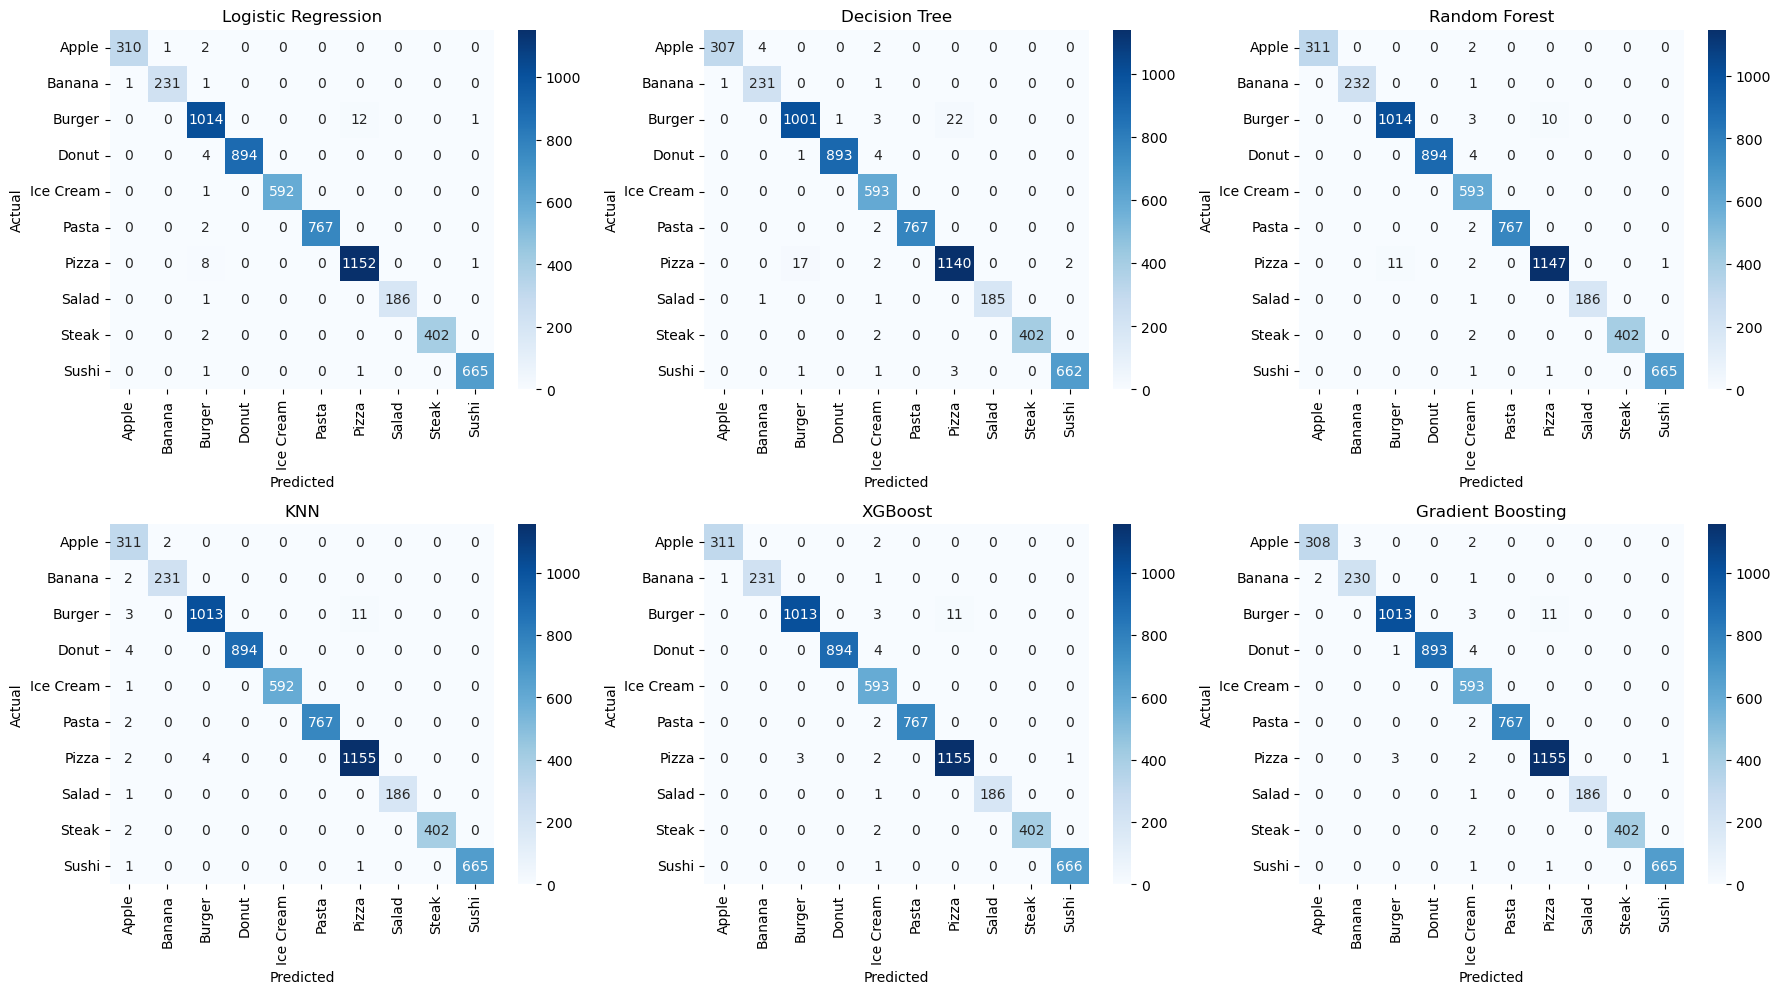

In [19]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
    
}

#Train and Evaluate Models
results = {}

for name, model in models.items():
    print(f"\n Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f" Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    results[name] = {
        "model": model,
        "accuracy": acc,
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

#Visualize Confusion Matrices
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result["confusion_matrix"], annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()